# PixelMind — Week 5: Face Detection with Haar Cascades

**Phase 1: Classical Computer Vision — Part 5 of 5**

This notebook is part of **PixelMind**, my 52-week computer vision learning journey.

After working through filters, features, contours, and color tracking, this week focuses on one of the most classic computer vision tasks: **face detection**.

The core question for this week:

> *How can a computer reliably locate human faces in images and video in real time?*

This notebook explores the classical **Viola–Jones Haar Cascade** approach for face and eye detection.


## Objectives for Week 5

- Understand the basics of Viola–Jones face detection  
- Load and use pretrained Haar cascade models  
- Detect faces in static images  
- Detect faces and eyes in webcam/video input  
- Draw bounding boxes around detected regions  


In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

## Step 1: Understanding Haar Cascades (Viola–Jones)

The Viola–Jones face detector relies on several key ideas:

- Haar-like rectangular features  
- Integral images for fast computation  
- AdaBoost for feature selection  
- Cascade stages for efficient detection  

What makes this approach notable is its strong optimization for real-time performance, even on relatively modest hardware.

In this notebook, we use OpenCV’s pretrained Haar cascade models rather than training from scratch.


## Step 2: Loading the Pretrained Cascade

OpenCV provides pretrained XML files for common detectors.

Important preprocessing note:

Haar cascades operate best on **grayscale images**, so conversion from BGR is required before detection.


In [3]:
# Load pretrained cascades from OpencV
face_cascade = cv.CascadeClassifier(
    cv.data.haarcascades + "haarcascade_frontalface_default.xml"
)

eye_cascade = cv.CascadeClassifier(
    cv.data.haarcascades + "haarcascade_eye.xml"
)

print("Face cascade loaded:", not face_cascade.empty())
print("Eye cascade loaded:", not eye_cascade.empty())

Face cascade loaded: True
Eye cascade loaded: True


## Step 3: Face Detection on Images

Using the loaded classifier, faces are detected with `detectMultiScale`.

Key parameters:

- **scaleFactor** — controls image pyramid scaling  
- **minNeighbors** — affects false positive suppression  
- **minSize** — minimum detectable face size  

Tuning these parameters significantly affects performance and accuracy.


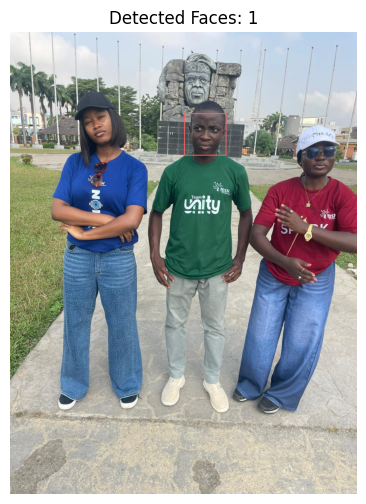

In [8]:
# Load sample image
image = cv.imread("../data/pictures/pics/img_n_34.jpg")
rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)
gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

# Improve contrast for Haar features
gray = cv.equalizeHist(gray)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.2,
    minNeighbors=5,
    minSize=(30, 30)
)

output = rgb.copy()
for (x, y, w, h) in faces:
    cv.rectangle(output, (x, y), (x+w, y+h), (255, 100, 100), 3)

plt.figure(figsize=(6, 6))
plt.imshow(output)
plt.title(f"Detected Faces: {len(faces)}")
plt.axis("off")
plt.show()

## Step 4: Eye Detection Within Faces

To make detection more structured:

1. Detect faces  
2. Extract the face region of interest (ROI)  
3. Detect eyes within the face  

This hierarchical detection reduces false positives and improves interpretability.


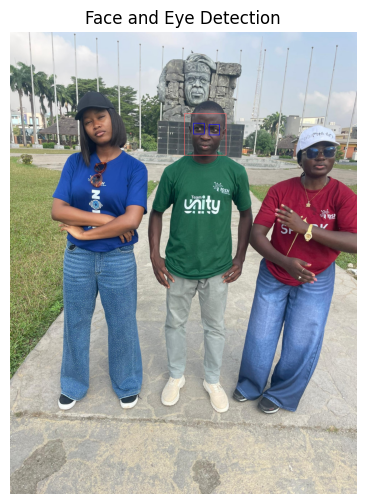

In [29]:
output = image.copy()

for (x, y, w, h) in faces:
    # Draw face box
    cv.rectangle(output, (x, y), (x+w, y+h), (100, 100, 255), 2)

    roi_gray = gray[y:y+h, x:x+w]
    roi_color = output[y:y+h, x:x+w]

    eyes = eye_cascade.detectMultiScale(roi_gray, 1.1, 4)

    for (ex, ey, ew, eh) in eyes:
        cv.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (255, 0, 0), 2)


plt.figure(figsize=(6,6))
plt.imshow(cv.cvtColor(output, cv.COLOR_BGR2RGB))
plt.title("Face and Eye Detection")
plt.axis("off")
plt.show()

## Step 5: Real-Time Face Detection (Webcam)

The final step applies the full pipeline to live webcam input.

Pipeline:

- Capture frame  
- Convert to grayscale  
- Detect faces  
- Draw bounding boxes  
- Display in real time  

This stage highlights real-time performance considerations.


In [11]:
cap = cv.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=4,
        # minSize=(30, 30)
    )

    for (x, y, w, h) in faces:
        cv.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)

    cv.imshow("Real-Time Face Detection", frame)

    if cv.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv.destroyAllWindows()

## Tools Used

- Python  
- OpenCV  
- Haar Cascade XML classifiers  

Key OpenCV components:

- `CascadeClassifier`  
- `detectMultiScale`  
- Video capture utilities  

All methods used this week are **classical computer vision** — no deep learning involved.
